# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

# Mean Reversion Strategy on AUDCAD

Mean reversion trading assumes the prices will move back to mean. Thus, whenever prices are too far from the mean we will take a position (Long or Short) and exit when the price reverts to mean.

In the below example, the mean reversion strategy is implemented on AUDCAD.

## Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import warnings 
warnings.filterwarnings('ignore')

## Read data from CSV
The price data for AUDCAD is saved in a CSV file. This data is available in the downloadable unit of this course in the last section.

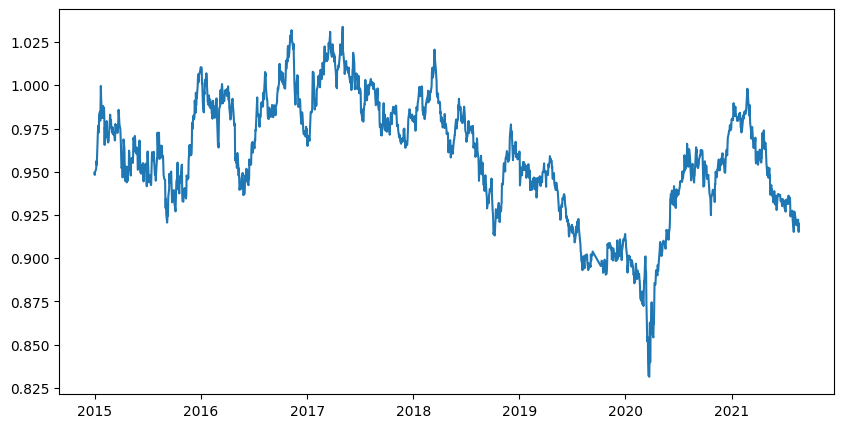

In [2]:
df = pd.read_csv('../data_modules/AUDCAD.csv',
                 index_col=0, parse_dates=True,  header=0)
plt.figure(figsize=(10, 5))
plt.plot(df.Close)
plt.show()

## Moving average and moving standard deviation

Moving average is calculated using pandas rolling().mean() function as shown below: 

<B>DataFrame.column_name.rolling(lookback_period).mean()</B>

Standard deviation is calculated using pandas rolling().std() function as shown below: 

<B>DataFrame.column_name.rolling(lookback_period).std()</B>

In [3]:
lookback = 5
# Moving Average
df['moving_average'] = df['Close'].rolling(lookback).mean()

# Moving Standard Deviation
df['moving_std_dev'] = df['Close'].rolling(lookback).std()
df.head(7)

,Open,High,Low,Close,Volume,moving_average,moving_std_dev
Date,,,,,,,
2014-12-31,0.94962,0.95210,0.94570,0.94940,0,NaN,NaN
2015-01-01,0.94816,0.94816,0.94816,0.94816,0,NaN,NaN
2015-01-02,0.95010,0.95220,0.94550,0.94981,0,NaN,NaN
2015-01-05,0.95150,0.95451,0.94910,0.95110,0,NaN,NaN
2015-01-06,0.95173,0.95827,0.95070,0.95190,0,0.950074,0.001464
2015-01-07,0.95610,0.95820,0.95110,0.95620,0,0.951434,0.003017
2015-01-08,0.95454,0.96006,0.95440,0.95400,0,0.952602,0.002522


## Upper band and lower band

The upper band is +0.5 * standard deviations above the moving average and the lower band is -0.5 * standard deviation below the moving average.


In [4]:
df['upper_band'] = df.moving_average + 0.5*df.moving_std_dev
df['lower_band'] = df.moving_average - 0.5*df.moving_std_dev

## Long entry and long exit

Long_entry is set to True value whenever the price falls below the lower band and False otherwise.

Long_exit is set to True value whenever the prices mean-reverts to the current moving average (prices >= moving average) and False otherwise.


In [5]:
df['long_entry'] = df.Close < df.lower_band
df['long_exit'] = df.Close >= df.moving_average
df.head(7)

,Open,High,Low,Close,Volume,moving_average,moving_std_dev,upper_band,lower_band,long_entry,long_exit
Date,,,,,,,,,,,
2014-12-31,0.94962,0.95210,0.94570,0.94940,0,NaN,NaN,NaN,NaN,False,False
2015-01-01,0.94816,0.94816,0.94816,0.94816,0,NaN,NaN,NaN,NaN,False,False
2015-01-02,0.95010,0.95220,0.94550,0.94981,0,NaN,NaN,NaN,NaN,False,False
2015-01-05,0.95150,0.95451,0.94910,0.95110,0,NaN,NaN,NaN,NaN,False,False
2015-01-06,0.95173,0.95827,0.95070,0.95190,0,0.950074,0.001464,0.950806,0.949342,False,True
2015-01-07,0.95610,0.95820,0.95110,0.95620,0,0.951434,0.003017,0.952942,0.949926,False,True
2015-01-08,0.95454,0.96006,0.95440,0.95400,0,0.952602,0.002522,0.953863,0.951341,False,True


## Short entry and short exit

The Short entry is set to True value whenever the price rises above the upper band and False otherwise.

The Short exit is set to True value whenever the prices mean-reverts to the current moving average (prices <= moving average) and False otherwise.

In [6]:
df['short_entry'] = df.Close > df.upper_band
df['short_exit'] = df.Close <= df.moving_average
df.head(7)

,Open,High,Low,Close,Volume,moving_average,moving_std_dev,upper_band,lower_band,long_entry,long_exit,short_entry,short_exit
Date,,,,,,,,,,,,,
2014-12-31,0.94962,0.95210,0.94570,0.94940,0,NaN,NaN,NaN,NaN,False,False,False,False
2015-01-01,0.94816,0.94816,0.94816,0.94816,0,NaN,NaN,NaN,NaN,False,False,False,False
2015-01-02,0.95010,0.95220,0.94550,0.94981,0,NaN,NaN,NaN,NaN,False,False,False,False
2015-01-05,0.95150,0.95451,0.94910,0.95110,0,NaN,NaN,NaN,NaN,False,False,False,False
2015-01-06,0.95173,0.95827,0.95070,0.95190,0,0.950074,0.001464,0.950806,0.949342,False,True,True,False
2015-01-07,0.95610,0.95820,0.95110,0.95620,0,0.951434,0.003017,0.952942,0.949926,False,True,True,False
2015-01-08,0.95454,0.96006,0.95440,0.95400,0,0.952602,0.002522,0.953863,0.951341,False,True,True,False


## Long positions and short positions

positions_long and positions_short columns is initialized with NaN values using np.nan. 1 is assigned to positions_long when long_entry is True and 0 when long_exit is True. Similarly, -1 and 0 are assigned to positions_short.

In [7]:
df['positions_long'] = np.nan
df.loc[df.long_entry, 'positions_long'] = 1
df.loc[df.long_exit, 'positions_long'] = 0

df['positions_short'] = np.nan
df.loc[df.short_entry, 'positions_short'] = -1
df.loc[df.short_exit, 'positions_short'] = 0

df.head(7)

,Open,High,Low,Close,Volume,moving_average,moving_std_dev,upper_band,lower_band,long_entry,long_exit,short_entry,short_exit,positions_long,positions_short
Date,,,,,,,,,,,,,,,
2014-12-31,0.94962,0.95210,0.94570,0.94940,0,NaN,NaN,NaN,NaN,False,False,False,False,NaN,NaN
2015-01-01,0.94816,0.94816,0.94816,0.94816,0,NaN,NaN,NaN,NaN,False,False,False,False,NaN,NaN
2015-01-02,0.95010,0.95220,0.94550,0.94981,0,NaN,NaN,NaN,NaN,False,False,False,False,NaN,NaN
2015-01-05,0.95150,0.95451,0.94910,0.95110,0,NaN,NaN,NaN,NaN,False,False,False,False,NaN,NaN
2015-01-06,0.95173,0.95827,0.95070,0.95190,0,0.950074,0.001464,0.950806,0.949342,False,True,True,False,0.0,-1.0
2015-01-07,0.95610,0.95820,0.95110,0.95620,0,0.951434,0.003017,0.952942,0.949926,False,True,True,False,0.0,-1.0
2015-01-08,0.95454,0.96006,0.95440,0.95400,0,0.952602,0.002522,0.953863,0.951341,False,True,True,False,0.0,-1.0


## Fill NaN values

DataFrame.fillna() is used with parameter as method = 'ffill' to carry forward previous position if no entry or exit.


In [8]:
df = df.fillna(method='ffill')
df.head(7)

,Open,High,Low,Close,Volume,moving_average,moving_std_dev,upper_band,lower_band,long_entry,long_exit,short_entry,short_exit,positions_long,positions_short
Date,,,,,,,,,,,,,,,
2014-12-31,0.94962,0.95210,0.94570,0.94940,0,NaN,NaN,NaN,NaN,False,False,False,False,NaN,NaN
2015-01-01,0.94816,0.94816,0.94816,0.94816,0,NaN,NaN,NaN,NaN,False,False,False,False,NaN,NaN
2015-01-02,0.95010,0.95220,0.94550,0.94981,0,NaN,NaN,NaN,NaN,False,False,False,False,NaN,NaN
2015-01-05,0.95150,0.95451,0.94910,0.95110,0,NaN,NaN,NaN,NaN,False,False,False,False,NaN,NaN
2015-01-06,0.95173,0.95827,0.95070,0.95190,0,0.950074,0.001464,0.950806,0.949342,False,True,True,False,0.0,-1.0
2015-01-07,0.95610,0.95820,0.95110,0.95620,0,0.951434,0.003017,0.952942,0.949926,False,True,True,False,0.0,-1.0
2015-01-08,0.95454,0.96006,0.95440,0.95400,0,0.952602,0.002522,0.953863,0.951341,False,True,True,False,0.0,-1.0


## Positions

The positions column is created by adding positions_long and positions_short.


In [9]:
df['positions'] = df.positions_long + df.positions_short

## Cumulative strategy returns

Strategy returns are calculated by multiplying previous day position (long or short) with daily returns and then, cumulative strategy returns are computed using cumprod() function. 

Please note that this code is for backtesting and not for the live environment as it does not include the factors such as transaction cost, slippage etc. For live-environment simulations, you can use Blueshift.

In [10]:
# Calculate daily returns
df['prices_difference'] = df.Close - df.Close.shift(1)
df['daily_returns'] = df.prices_difference / df.Close.shift(1)

# Calculate strategy returns
df['strategy_returns'] = df.positions.shift(1) * df.daily_returns

# Calculate cumulative returns
df['cumret'] = (df.strategy_returns+1).cumprod()

### Plot cumulative strategy returns

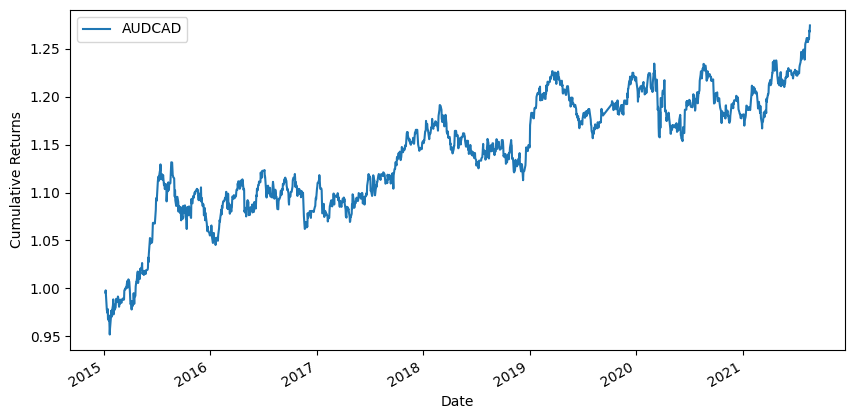

In [11]:
df.cumret.plot(label='AUDCAD', figsize=(10, 5))
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

In the next unit, there will be an interactive exercise to implement mean reversion strategy on AUDCAD. All the best!<br><br>